# House Price Prediction — Regression Analysis

**Internship Project — Week 1**

**Name:** Poorvi Sharma
**Dataset:** Housing Prices Dataset (Kaggle — yasserh/housing-prices-dataset)
**Objective:** Build a regression model that predicts house prices based on property features, and identify which features most strongly influence price.

---

## Task 1 — Data Loading & Exploration

In this section, the dataset is loaded using Pandas, and a first look is taken at its structure: the number of rows and columns, the data types, the target variable, and whether any values are missing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load the dataset
df = pd.read_csv("Housing.csv")
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [2]:
# First 10 rows of the dataset
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
# Shape of the dataset
rows, cols = df.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {cols}")

Number of rows: 545
Number of columns: 13


**Target column:** `price` — this is the value we want to predict.

**Feature columns:** all the remaining 12 columns — `area`, `bedrooms`, `bathrooms`, `stories`, `mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `parking`, `prefarea`, and `furnishingstatus`. These describe the physical and locational characteristics of each house.

In [4]:
# Data types of each column
df.dtypes

price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

In [5]:
# Check for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

**Observation:** The dataset has no missing values in any column. This is good news — it means we don't need to impute or drop rows for missing data, though the cleaning code below is still written generically so it would handle missing values if they were present.

## Task 2 — Data Cleaning

Even though this dataset has no missing values, the steps below are written to be robust — they would correctly handle missing values and duplicates if either were present. The main work here is converting the yes/no categorical columns and the `furnishingstatus` column into numeric form so the model can use them.

In [6]:
# Step 1: Handle missing values (numeric columns -> fill with median, categorical -> fill with mode)
# This is written generically even though this dataset has none.
df_clean = df.copy()

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['int64', 'float64']:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values after handling:", df_clean.isnull().sum().sum())

Missing values after handling: 0


In [7]:
# Step 2: Remove duplicate rows, if any
duplicate_count = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicate_count}")

df_clean = df_clean.drop_duplicates()
print(f"Shape after removing duplicates: {df_clean.shape}")

Duplicate rows found: 0
Shape after removing duplicates: (545, 13)


In [8]:
# Step 3: Convert binary yes/no columns into numeric form (1 = yes, 0 = no)
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'yes': 1, 'no': 0})

df_clean[binary_cols].head()

,mainroad,guestroom,basement,hotwaterheating,airconditioning,prefarea
0,1,0,0,0,1,1
1,1,0,0,0,1,0
2,1,0,1,0,0,1
3,1,0,1,0,1,1
4,1,1,1,0,1,0


In [9]:
# Step 4: One-hot encode the 'furnishingstatus' column (it has 3 categories, not just yes/no)
df_clean = pd.get_dummies(df_clean, columns=['furnishingstatus'], drop_first=True)

# drop_first=True avoids redundant columns (e.g. if both "semi-furnished" and
# "unfurnished" are 0, that already implies "furnished")
df_clean.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,False,False


In [10]:
# Step 5: Confirm all columns are now numeric and meaningful for prediction
print("Final cleaned dataset shape:", df_clean.shape)
print()
print(df_clean.dtypes)

Final cleaned dataset shape: (545, 14)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


**Cleaning summary:** All categorical columns have been converted into numeric form (binary 1/0 for yes/no fields, and one-hot encoding for `furnishingstatus`). No rows were dropped since there were no duplicates or missing values. All 13 original columns were kept, since each one is a meaningful, plausible driver of house price — none were dropped at this stage.

## Task 3 — Model Building

The cleaned dataset is split into training (80%) and test (20%) sets. Two regression models are trained — Linear Regression and Random Forest Regressor — and compared using three evaluation metrics: **MAE** (Mean Absolute Error), **RMSE** (Root Mean Squared Error), and **R² Score**.

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate features (X) and target (y)
X = df_clean.drop('price', axis=1)
y = df_clean['price']

# 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} rows")
print(f"Test set size: {X_test.shape[0]} rows")

Training set size: 436 rows
Test set size: 109 rows


In [12]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print(f"  MAE  : {lr_mae:,.2f}")
print(f"  RMSE : {lr_rmse:,.2f}")
print(f"  R2   : {lr_r2:.4f}")

Linear Regression Performance
  MAE  : 970,043.40
  RMSE : 1,324,506.96
  R2   : 0.6529


In [13]:
# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance")
print(f"  MAE  : {rf_mae:,.2f}")
print(f"  RMSE : {rf_rmse:,.2f}")
print(f"  R2   : {rf_r2:.4f}")

Random Forest Regressor Performance
  MAE  : 1,022,560.05
  RMSE : 1,401,496.84
  R2   : 0.6114


In [14]:
# Side-by-side comparison
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest Regressor,1.022560e+06,1.401497e+06,0.611402


**Model comparison takeaway:** On this dataset, Linear Regression performed slightly better than Random Forest (higher R², lower MAE and RMSE). This is a genuinely interesting result rather than the "expected" outcome — it happens because the dataset is fairly small (545 rows) and most features have a fairly linear, additive relationship with price, which plays to the strengths of a simple linear model. Random Forest tends to shine more on larger datasets with complex non-linear interactions; here, the added complexity doesn't pay off and the model slightly overfits the training data instead.

## Task 4 — Visualization

Three charts are produced below: the distribution of house prices, a correlation heatmap of all features against price, and an actual-vs-predicted scatter plot comparing both models. All charts are also saved as `.png` files in the `charts/` folder.

In [15]:
import os
os.makedirs("charts", exist_ok=True)

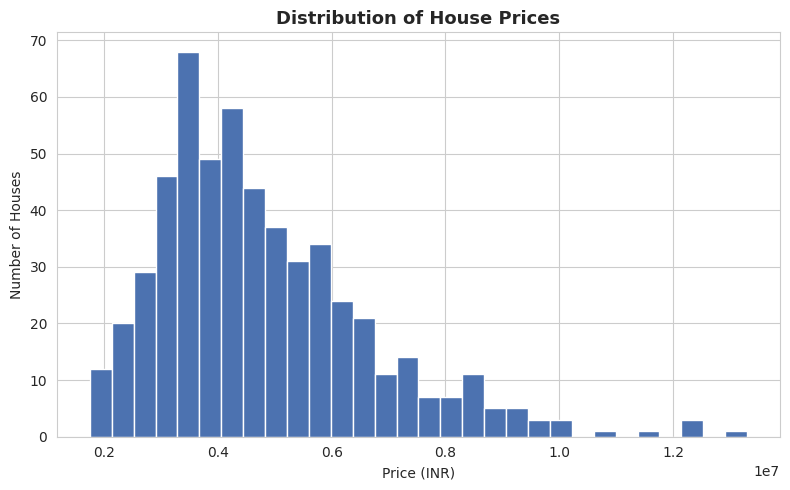

In [16]:
# Chart 1: Histogram of house price distribution
plt.figure(figsize=(8, 5))
plt.hist(df['price'], bins=30, color='#4C72B0', edgecolor='white')
plt.title('Distribution of House Prices', fontsize=13, fontweight='bold')
plt.xlabel('Price (INR)')
plt.ylabel('Number of Houses')
plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=150)
plt.show()

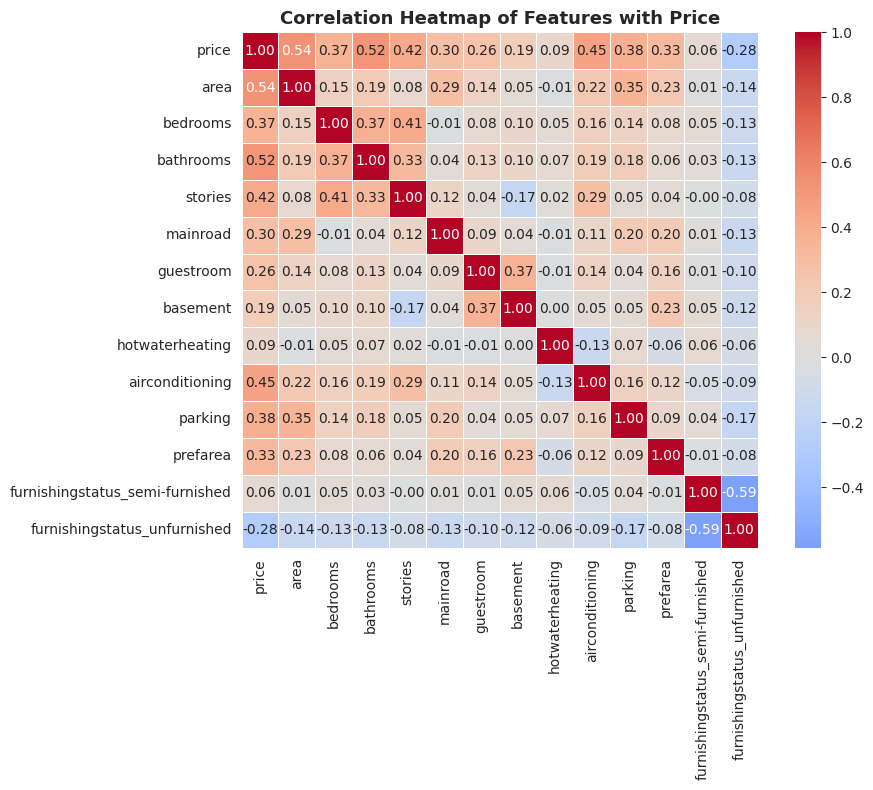

In [17]:
# Chart 2: Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Features with Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=150)
plt.show()

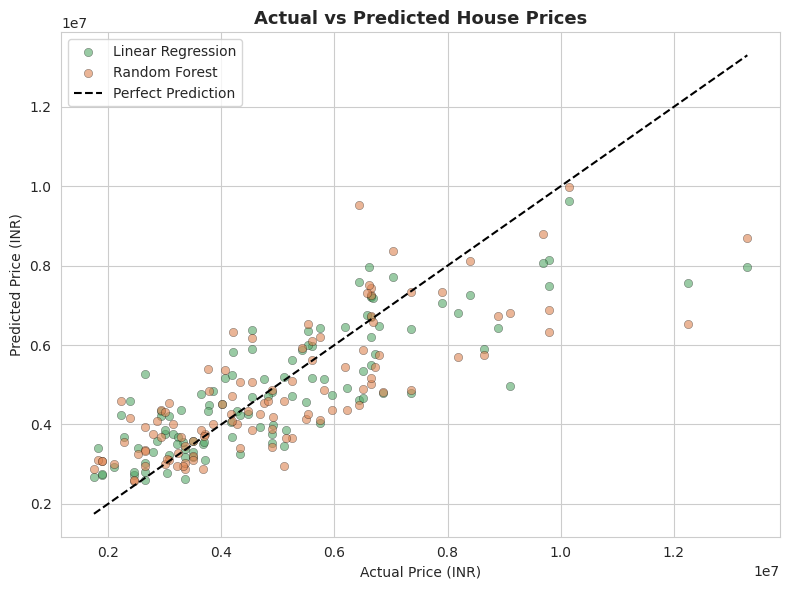

In [18]:
# Chart 3: Actual vs Predicted price scatter plot (both models)
plt.figure(figsize=(8, 6))
plt.scatter(y_test, lr_pred, alpha=0.6, color='#55A868', label='Linear Regression', edgecolor='k', linewidth=0.3)
plt.scatter(y_test, rf_pred, alpha=0.6, color='#DD8452', label='Random Forest', edgecolor='k', linewidth=0.3)

lims = [min(y_test.min(), lr_pred.min(), rf_pred.min()), max(y_test.max(), lr_pred.max(), rf_pred.max())]
plt.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect Prediction')

plt.xlabel('Actual Price (INR)')
plt.ylabel('Predicted Price (INR)')
plt.title('Actual vs Predicted House Prices', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=150)
plt.show()

**Chart 3 reading guide:** Points lying close to the dashed diagonal line are well-predicted; points far from it are poorly predicted. Both models do reasonably well in the mid-price range but tend to underpredict the most expensive houses — visible as orange and green dots sitting noticeably below the diagonal at the top right.

## Task 5 — Insights & Summary

In [19]:
# Feature importance from Random Forest (helps identify which features matter most)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Feature Importance (Random Forest):")
importances

Feature Importance (Random Forest):


area                               0.467917
bathrooms                          0.151526
airconditioning                    0.062718
parking                            0.057820
stories                            0.057137
bedrooms                           0.048608
furnishingstatus_unfurnished       0.034998
basement                           0.030804
prefarea                           0.030519
hotwaterheating                    0.017255
guestroom                          0.016638
furnishingstatus_semi-furnished    0.013764
mainroad                           0.010296
dtype: float64

In [20]:
# Correlation of each feature with price (helps cross-check feature importance)
price_corr = df_clean.corr()['price'].drop('price').sort_values(ascending=False)
print("Correlation with Price:")
price_corr

Correlation with Price:


area                               0.535997
bathrooms                          0.517545
airconditioning                    0.452954
stories                            0.420712
parking                            0.384394
bedrooms                           0.366494
prefarea                           0.329777
mainroad                           0.296898
guestroom                          0.255517
basement                           0.187057
hotwaterheating                    0.093073
furnishingstatus_semi-furnished    0.063656
furnishingstatus_unfurnished      -0.280587
Name: price, dtype: float64

### Summary of Findings

**Which features influence house price the most?** `area` is by far the strongest driver of price, both by correlation (0.54) and by Random Forest feature importance (about 47%). `bathrooms` and `airconditioning` are the next most influential factors, followed by `stories` and `parking`. Interestingly, `bedrooms` matters less than `bathrooms` — a house with more bathrooms tends to command a noticeably higher price than one with simply more bedrooms.

**How accurate was the model, in plain terms?** The Linear Regression model explains about 65% of the variation in house prices (R² = 0.65), with an average prediction error (MAE) of roughly ₹9.7 lakh. That means on a typical house, our price estimate is usually off by under ₹10 lakh — useful as a ballpark estimate for negotiation, but not precise enough to set a final asking price without human judgment. Random Forest performed marginally worse here (R² = 0.61), which was a bit surprising given it's usually the stronger model.

**What surprised me in the data?** Two things stood out. First, `furnishingstatus` being "unfurnished" has a fairly strong *negative* correlation with price (-0.28) — unfurnished houses are reliably cheaper, more so than I expected from a simple cosmetic feature. Second, the simpler Linear Regression model beating Random Forest was unexpected; it's a good reminder that more complex models aren't automatically better, especially on smaller datasets like this one with 545 rows.

**Recommendation for a real estate business:** Since `area` and `bathrooms` are the two biggest, most controllable price drivers, a real estate business should prioritize accurately measuring and prominently advertising these two figures for every listing — and should consider that adding a bathroom during renovation may raise resale value more than adding an extra bedroom of the same size.